### Orchestrator-worker

Orchestrator가 입력에 따라 작업을 나누고, 여러 Worker가 동적으로 병렬 실행한 결과를 모으는 방법을 배운다.

```
START → Orchestrator ─┬→ Worker
                      ├→ Worker ─→ 결과 종합 → END
                      └→ Worker
```

In [1]:
import operator
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from pydantic import BaseModel, Field

load_dotenv(override=True)

MODEL_NAME = "gemini-3.6-flash"
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

### Orchestrator-worker와 Send API

고정 Fan-out은 그래프를 만들 때 작업의 종류와 수가 정해진다. Orchestrator-worker 패턴에서는 Orchestrator가 사용자 요청을 분석하여 실행 시점에 필요한 작업을 계획하고, `Send` API로 각 작업을 Worker에 전달한다.

`Send(노드이름, state)`는 지정한 Worker 노드를 새로운 입력 State로 실행한다. 라우팅 함수가 `Send` 객체의 리스트를 반환하면 리스트 길이만큼 동적 Fan-out이 일어난다. 작업 수를 미리 정하지 않아도 되므로 사용자 요청마다 서로 다른 수의 Worker를 실행할 수 있다.

```
START → create_plan(Orchestrator) ─┬→ analyze_task(Worker) ─┐
                                  ├→ analyze_task(Worker) ─┼→ make_report → END
                                  └→ analyze_task(Worker) ─┘
```

그래프의 실행 흐름은 다음과 같다.

- `create_plan`이 사용자 요청을 분석하여 작업 목록을 만든다.
- `assign_workers`가 작업마다 하나의 `Send` 객체를 만든다.
- 여러 `analyze_task`가 서로 독립된 입력을 받아 실행된다.
- 각 Worker의 결과가 `results`에 병합된다.
- 모든 Worker가 완료되면 `make_report`가 결과를 하나의 보고서로 종합한다.

### 전체 State와 Worker State

`ReportState`는 그래프 전체가 공유하는 상태다. 원본 요청, Orchestrator가 만든 작업 목록, Worker 결과, 최종 보고서를 저장한다. 반면 `WorkerState`는 Worker 한 개가 담당 작업을 처리하는 데 필요한 값만 가진다.

Worker들은 같은 `WorkerState` 스키마를 사용하지만, 각 `Send`가 전달하는 State 값은 서로 독립적이다. 예를 들어 `Send("analyze_task", {"task_id": 0, "title": "비용 분석", ...})`와 `Send("analyze_task", {"task_id": 1, "title": "위험 분석", ...})`는 같은 `analyze_task` 함수를 실행하지만 서로 다른 입력을 받는다. 따라서 Worker가 공유 State에서 자신의 작업을 다시 찾을 필요 없이 전달받은 State를 바로 사용하면 된다.

`task_id`는 Worker를 서로 다른 객체로 만드는 값이 아니다. 병렬 실행이 끝난 뒤 하나의 리스트에 합쳐진 결과가 어느 작업에서 나왔는지 식별하고, 원래 계획 순서로 정렬하기 위한 구분자다.

`results: Annotated[list, operator.add]`의 `operator.add`는 병렬 실행 결과를 합치는 **reducer**다. 여러 Worker가 각각 `results` 리스트를 반환하면 기존 값을 덮어쓰지 않고 하나의 리스트로 이어 붙인다. reducer가 없으면 여러 Worker가 같은 State 키를 동시에 갱신할 때 충돌이 발생할 수 있다.

In [2]:
class AnalysisTask(BaseModel):
    title: str = Field(description="분석 항목 제목")
    description: str = Field(description="분석할 내용")


class AnalysisPlan(BaseModel):
    tasks: list[AnalysisTask] = Field(description="보고서 작성에 필요한 분석 작업")


class ReportState(TypedDict):
    request: str
    tasks: list[AnalysisTask]
    results: Annotated[list, operator.add]
    final_report: str


class WorkerState(TypedDict):
    request: str
    task_id: int
    title: str
    description: str


def create_plan(state: ReportState):
    """사용자 요청을 분석하여 필요한 작업을 계획한다."""
    planner = llm.with_structured_output(AnalysisPlan)
    plan = planner.invoke(
        f"다음 요청에 대한 분석 보고서를 작성하려고 한다. "
        f"필요한 분석 작업을 3~5개로 나눠줘.\n\n요청: {state['request']}"
    )
    return {"tasks": plan.tasks}


def assign_workers(state: ReportState):
    """계획된 작업마다 Worker를 생성한다."""
    return [
        Send(
            "analyze_task",
            {
                "request": state["request"],
                "task_id": task_id,
                "title": task.title,
                "description": task.description,
            },
        )
        for task_id, task in enumerate(state["tasks"])
    ]


def analyze_task(state: WorkerState):
    result = llm.invoke(
        f"전체 요청을 고려하여 담당 항목을 구체적으로 분석해줘.\n\n"
        f"전체 요청: {state['request']}\n"
        f"담당 항목: {state['title']}\n"
        f"분석 내용: {state['description']}"
    )
    print(f"[analyze_task] '{state['title']}' 완료")
    return {
        "results": [{
            "task_id": state["task_id"],
            "title": state["title"],
            "content": result.text,
        }]
    }


def make_report(state: ReportState):
    sorted_results = sorted(state["results"], key=lambda item: item["task_id"])
    all_results = "\n\n".join(
        f"### {item['title']}\n{item['content']}" for item in sorted_results
    )
    result = llm.invoke(
        f"다음 요청과 분석 결과를 바탕으로 하나의 보고서를 작성해줘.\n\n"
        f"요청: {state['request']}\n\n{all_results}"
    )
    return {"final_report": result.text}

### Orchestrator, 라우팅 함수, Worker

`create_plan`은 Orchestrator 역할을 한다. `with_structured_output(AnalysisPlan)`을 사용하므로 LLM의 응답을 문자열이 아니라 `AnalysisTask` 목록으로 받을 수 있다. 이 목록의 길이가 실행할 Worker 수를 결정한다.

`assign_workers`는 일반 노드가 아니라 **라우팅 함수**다. 각 작업을 `Send("analyze_task", worker_state)`로 바꾸어 반환한다. 두 번째 인자의 딕셔너리는 해당 Worker만 받는 입력이며 `WorkerState`의 구조와 맞아야 한다.

`analyze_task`는 모든 작업에 공통으로 사용하는 Worker 노드다. Worker마다 입력값은 다르지만 같은 함수를 실행하고, 결과 한 개를 리스트에 담아 반환한다. 병렬로 실행되므로 완료 순서는 작업 목록의 순서와 다를 수 있다.

`make_report`는 병합된 결과를 종합하는 노드다. 병렬 완료 순서에 영향을 받지 않도록 `task_id`로 결과를 다시 정렬한 뒤 최종 보고서를 생성한다.

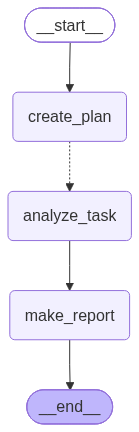

In [3]:
graph_builder = StateGraph(ReportState)

graph_builder.add_node("create_plan", create_plan)
graph_builder.add_node("analyze_task", analyze_task)
graph_builder.add_node("make_report", make_report)

graph_builder.add_edge(START, "create_plan")
# Orchestrator가 만든 작업 수만큼 동적 Fan-out
graph_builder.add_conditional_edges("create_plan", assign_workers, ["analyze_task"])
graph_builder.add_edge("analyze_task", "make_report")
graph_builder.add_edge("make_report", END)

send_graph = graph_builder.compile()
display(Image(send_graph.get_graph().draw_mermaid_png()))

### 동적 Fan-out과 Fan-in

`add_conditional_edges`는 `create_plan` 실행 후 `assign_workers`를 호출한다. 이 함수가 반환한 `Send` 수만큼 `analyze_task`가 동적으로 실행되는 과정이 **Fan-out**이다.

각 `analyze_task`에서 `make_report`로 이어지는 간선은 **Fan-in**을 만든다. LangGraph는 같은 단계에서 생성된 Worker들이 모두 완료될 때까지 기다린 뒤, reducer로 합쳐진 전체 `results`를 `make_report`에 전달한다. 따라서 Worker 하나가 끝날 때마다 보고서를 따로 만드는 것이 아니라 모든 분석 결과를 한 번에 종합한다.

아래 실행에서는 `stream_mode="updates"`를 사용한다. 노드가 State를 갱신할 때마다 `{노드 이름: 갱신 내용}` 형태의 값을 받아 Orchestrator의 계획, 각 Worker의 완료, 최종 보고서 생성을 순서대로 확인할 수 있다. Worker의 출력 순서는 매번 달라질 수 있으며, 이는 병렬 실행의 자연스러운 결과다.

In [ ]:
request = "소규모 카페가 키오스크를 도입할 때 기대 효과와 위험을 분석해줘."

for chunk in send_graph.stream(
    {"request": request},
    stream_mode="updates",
):
    for node_name, update in chunk.items():
        if node_name == "create_plan":
            tasks = update["tasks"]
            print("\n" + "=" * 60)
            print(f"[Orchestrator] 분석 작업 {len(tasks)}개 생성")
            print("-" * 60)
            for task in tasks:
                print(f"• {task.title}")

        elif node_name == "analyze_task":
            item = update["results"][0]
            preview = " ".join(item["content"].split())[:150]
            print("\n" + "=" * 60)
            print(f"[Worker 완료] {item['title']}")
            print("-" * 60)
            print(f"{preview}...")

        elif node_name == "make_report":
            preview = " ".join(update["final_report"].split())[:500]
            print("\n" + "=" * 60)
            print("[최종 보고서]")
            print("-" * 60)
            print(f"{preview}...")
            print("=" * 60)

### Rate Limiting

**Rate Limit**은 LLM API Provider가 안정적인 서비스 운영과 과도한 사용 방지를 위해 일정 시간 동안의 요청량을 제한하는 정책이다. 제한 기준과 한도는 Provider, 모델, 사용 등급에 따라 다르며, 일반적으로 다음 항목을 사용한다.

- **RPM (Requests Per Minute)**: 분당 요청 수
- **TPM (Tokens Per Minute)**: 분당 처리 토큰 수
- **RPD (Requests Per Day)**: 일일 요청 수
- **동시 요청 수**: 같은 시점에 처리할 수 있는 요청 수

한도를 초과하면 일반적으로 `429 Too Many Requests` 또는 이에 대응하는 오류가 발생한다. Orchestrator가 작업 5개를 만들면 Worker의 LLM 요청도 짧은 시간에 최대 5개가 시작될 수 있으므로 순차 실행보다 Rate Limit에 걸리기 쉽다.

LangGraph의 `max_concurrency` 설정으로 한 번의 그래프 실행에서 동시에 수행할 수 있는 태스크 수를 제한할 수 있다. 전체 Worker 수를 줄이는 설정은 아니며, 실행 중인 Worker가 끝나면 대기하던 다음 Worker가 시작된다. 아래 예제는 8개 주제를 모두 분석하되 최대 3개 태스크만 동시에 실행한다.

`max_concurrency`는 순간적으로 요청이 몰리는 것을 완화하지만 RPM이나 TPM을 직접 계산하지는 않는다. 실제 Rate Limit에 대응하려면 재시도, exponential backoff, 요청 속도 제한 등을 함께 사용해야 한다. 특정 API 호출이나 코드 블록만 제한해야 하는 경우에는 `asyncio.Semaphore`를 사용할 수 있다.

In [ ]:
class RateLimitState(TypedDict):
    topics: list[str]
    results: Annotated[list, operator.add]


class RateLimitItemState(TypedDict):
    topic: str


def dispatch_topics(state: RateLimitState):
    return [
        Send("analyze_with_limit", {"topic": topic})
        for topic in state["topics"]
    ]


def analyze_with_limit(state: RateLimitItemState):
    topic = state["topic"]
    print(f"[시작] {topic} (현재 동시 실행 중)")
    result = llm.invoke(f"'{topic}'에 대해 한 문장으로 설명해줘.")
    print(f"[완료] {topic}")
    return {"results": [f"[{topic}] {result.text}"]}


graph_builder = StateGraph(RateLimitState)
graph_builder.add_node("analyze_with_limit", analyze_with_limit)

graph_builder.add_conditional_edges(START, dispatch_topics, ["analyze_with_limit"])
graph_builder.add_edge("analyze_with_limit", END)

rate_limit_graph = graph_builder.compile()
display(Image(rate_limit_graph.get_graph().draw_mermaid_png()))

In [ ]:
topics = ["AI", "블록체인", "IoT", "클라우드", "5G", "메타버스", "드론", "AR/VR"]

result = rate_limit_graph.invoke(
    {"topics": topics},
    config={"max_concurrency": 3},
)

print(f"총 {len(topics)}개 주제, 동시 최대 3개 제한")
print(f"\n=== 결과 ===")
for r in result["results"]:
    print(r)

### 실습: 맞춤형 학습 자료 생성

사용자의 학습 요청을 바탕으로 맞춤형 학습 자료를 만드는 Orchestrator-worker 그래프를 완성하세요. 사용자는 목차를 직접 입력하지 않으며, Orchestrator가 학습 대상과 시간을 고려하여 필요한 목차를 동적으로 생성해야 합니다.

```
학습 요청 → 목차 생성 ─┬→ 목차별 Worker ─┐
                       ├→ 목차별 Worker ─┼→ 학습 자료 완성
                       └→ 목차별 Worker ─┘
```

요구사항:

- Orchestrator가 요청에 적합한 목차를 3~5개 생성한다.
- 생성된 목차마다 Worker를 동적으로 실행하여 설명과 간단한 예제를 작성한다.
- Worker의 결과를 모아 하나의 학습 자료로 완성하고 실행 과정을 출력한다.

구현할 때는 다음 요소를 확인하세요.

- 구조화 출력을 위한 목차 항목 모델과 목차 모델
- 전체 요청과 병합 결과를 저장할 그래프 State
- 목차 한 개만 전달받는 Worker State
- 학습 요청을 3~5개 목차로 나누는 Orchestrator 함수
- 목차마다 `Send`를 생성하는 라우팅 함수
- 설명과 예제를 작성하는 Worker 함수
- 병렬 결과를 순서대로 정리하여 학습 자료로 만드는 종합 함수
- `stream_mode="updates"`를 이용한 실행 과정 출력

병렬 Worker의 완료 순서는 보장되지 않는다. 최종 학습 자료의 목차 순서를 유지하려면 각 항목에 순번을 함께 전달하고 종합 단계에서 정렬한다.

In [3]:
course_request = (
    "파이썬을 처음 배우는 비전공자를 위한 2시간 분량의 학습 자료를 만들어줘."
)

class CourseSection(BaseModel):
    title: str = Field(description="학습 목차 제목")
    description: str = Field(description="목차에서 설명할 학습 내용")


class CoursePlan(BaseModel):
    sections: list[CourseSection] = Field(description="학습 순서에 맞는 3~5개의 목차")

class CourseState(TypedDict):
    request: str
    sections: list[CourseSection]
    results: Annotated[list, operator.add]
    final_material: str


class CourseWorkerState(TypedDict):
    request: str
    section_id: int
    title: str
    description: str

def create_plan(state: CourseState):
    """사용자 요청을 분석하여 필요한 작업을 계획한다."""
    planner = llm.with_structured_output(CoursePlan)
    plan = planner.invoke(
        f"다음 학습 요청을 학습 순서에 맞는 목차 3~5개 목차로 나눠줘. "
        f"학습 요청 : {state['request']}"
    )
    return {"sections": plan.sections}


def assign_workers(state: CourseState):
    """계획된 작업마다 Worker를 생성한다."""
    return [
        Send(
            "create_section",
            {
                "request": state["request"],
                "section_id": section_id,
                "title": section.title,
                "description": section.description,
            },
        )
        for section_id, section in enumerate(state["sections"])
    ]


def create_section(state: CourseWorkerState):
    result = llm.invoke(
        f"전체 요청을 고려하여 담당 목차의 학습 내용을 작성해줘.\n\n"
        f"전체 요청: {state['request']}\n"
        f"목차 제목: {state['title']}\n"
        f"학습 내용: {state['description']}"
    )
    print(f"[create_section] '{state['title']}' 완료")
    return {
        "results": [{
            "section_id": state["section_id"],
            "title": state["title"],
            "content": result.text,
        }]
    }


def make_report(state: CourseState):
    sorted_results = sorted(state["results"], key=lambda item: item["section_id"])
    all_results = "\n\n".join(
        f"### {item['title']}\n{item['content']}" for item in sorted_results
    )
    result = llm.invoke(
        f"다음 학습 요청과 목차별 내용을 바탕으로 하나의 학습 자료를 완성해줘.\n\n"
        f"요청: {state['request']}\n\n{all_results}"
    )
    return {"final_material": result.text}

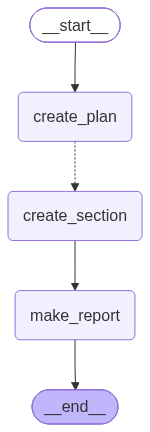

In [5]:
graph_builder = StateGraph(CourseState)

graph_builder.add_node("create_plan", create_plan)
graph_builder.add_node("create_section", create_section)
graph_builder.add_node("make_report", make_report)

graph_builder.add_edge(START, "create_plan")
# Orchestrator가 만든 작업 수만큼 동적 Fan-out
graph_builder.add_conditional_edges("create_plan", assign_workers, ["create_section"])
graph_builder.add_edge("create_section", "make_report")
graph_builder.add_edge("make_report", END)

send_graph = graph_builder.compile()
display(Image(send_graph.get_graph().draw_mermaid_png()))

In [ ]:
## 강사님 풀이

course_request = (
    "파이썬을 처음 배우는 비전공자를 위한 2시간 분량의 학습 자료를 만들어줘."
)
# 전체 : course
# 부분 : section 

# 여기서 나온 정보를 바탕으로 -> SectionState로 분배가 된다.
class Section(BaseModel):
    title: str = Field(description="수업 자료 제목")
    objective: str = Field(description="학습 목표")

class CoursePlan(BaseModel):
    sections: list[Section] = Field(description="수업자료의 제목, 학습 목표를 담은 리스트")


llm_with_courseplan_output = llm.with_structured_output(CoursePlan)

# 전체
class CourseState(TypedDict):
    request: str
    sections: list # structured output
    results: Annotated[list, operator.add] # 각각의 worker들이 작업한 것을 모아놓은 곳. 즉, 수업 자료들의 모음
    final_result: str # results를 하나의 str으로 모은 녀석.

# 부분
class SectionState(TypedDict):
    request: str
    title: str # 수업자료 제목
    objective: str # 학습 목표.
    order: int


# 계획을 짬 -> list로 나눈다.
def course_plan(state: CourseState):
    request = state['request']


    response = llm_with_courseplan_output.invoke(f"""
다음 <request>에 맞는 학습 목차를 만들어줘.
목차에는 수업자료의 제목과 학습 목표를 포함해줘.
<request>
{request}
</request>
""")
    return {'sections': response.sections} # response는 {sections: [Section, Section, Section]}

# 계획의 list를 worker에게 분배한다.
def assign_sections(state: CourseState):

    # sections = state['sections']
    # result = []
    # for index in range(len(sections)):
    #     section = sections[index]
    #     result.append(Send(
    #         'write_section', 
    #             {
    #                 'request': state['request'],
    #                 'title': section.title,
    #                 'objective': section.objective,
    #                 'order' : index
    #             }
    #     ) 
    #     )

    return [
        Send(
            'write_section', 
            {
                'request': state['request'],
                'title': section.title,
                'objective': section.objective,
                'order' : index
            }
    ) 
    for index, section in enumerate(state['sections'])
    ]

# worker
def write_section(state: SectionState):
    response = llm.invoke(f"""
다음 <request>에 따른 학습자료를 만들어줘.
학습 제목은 <title> 학습 목표는 <objective>야.
마크다운 형식으로 깔끔하게 작성해줘.

<request>
{state['request']}
<request>

<title>
{state['title']}
<title>

<objective>
{state['objective']}
<objective
""")
    # CourseState에 자료를 업데이트.
    return {'results' : [{
                            'title' : state['title'],
                            'objective' : state['objective'],
                            'content' : response.text,
                            'order': state['order']
                        }]}

# 각 worker들의 동작을 통합한다.
def merge_results(state : CourseState):
    results = state['results']
    results.sort(key=lambda x : x['order'])

    final_result = "\n\n".join([
        f"""
title : {result['title']} \n 
objective : {result['objective']}
content : {result['content']}
""" 
for result in results])

    return {'final_result' : final_result}

builder = StateGraph(CourseState)

builder.add_node('course_plan', course_plan)
builder.add_node('write_section', write_section)
builder.add_node('merge_results', merge_results)

builder.add_edge(START, 'course_plan')
builder.add_conditional_edges(
    'course_plan',
    assign_sections,
    ['write_section']
)
builder.add_edge('write_section', 'merge_results')
builder.add_edge('merge_results', END)

graph = builder.compile()



In [ ]:
## 강사님 풀이

result = graph.invoke({'request' : course_request})

print(result)

In [ ]:
## 강사님 풀이

print(result['final_result'])

In [ ]:
for item in graph.stream({'request' : course_request}):
    for node_name, update in item.items():
        print('---------------------')
        print(node_name)
        print(update)


## 추가 실습

면접 문제 생성

입력 : 지원자의 직무 / 경력 등 필요한 정보들  
orchestrator : 평가 역량(llm이 판단)  
worker : 하나의 역량에 대한 질문 생성.


In [15]:
## 한번 더 풀어보기

# 아웃풋 구조
class Section(BaseModel):
    classification: str = Field(description= "면접 질문 분류")
    evaluationCriteria: str = Field(description= "면접 질문 평가할 항목")

class InterviewPlan(BaseModel):
    section: list[Section] = Field(description= "면접 질문 리스트")

class QuestionAnswer(BaseModel):
    question: str = Field(description="면접 질문")
    answer: str = Field(description="면접 질문의 모범 답안")    

# 전체
class InterviewState(TypedDict):
    request: str
    sections: list[Section]
    results: Annotated[list, operator.add]
    final_result: str

# section(부분)
class SectionState(TypedDict):
    request: str
    classification: str
    evaluationCriteria: str

llm_with_interviewPlan_output = llm.with_structured_output(InterviewPlan)
llm_with_question_output = llm.with_structured_output(QuestionAnswer)

def interviewPlan(state: InterviewState):
    request = state["request"]
    """사용자에 request에 대한 면접에 필요한 항목과 평가할 내용을 생성한다."""
    response = llm_with_interviewPlan_output.invoke(f"""
    다음 {request}를 보고 면접 질문에 필요한 분류와 평가 항목을
    중복 없이 정확히 5개 만들어줘.
    """)
    return {"sections": response.section}

def question_workers(state: InterviewState):
    """생성된 분류와 평가 항목에 따라 worker를 생성한다."""
    return [
        Send(
            "question_section",
            {
                "request": state["request"],
                "classification": section.classification,
                "evaluationCriteria": section.evaluationCriteria
            }
        )
        for section in state["sections"]
    ]


def question_section(state: SectionState):
    classification = state["classification"]
    evaluationCriteria = state["evaluationCriteria"]

    response = llm_with_question_output.invoke(f"""
    {classification}와 {evaluationCriteria}를 보고 각 항목과 평가할 내용에 맞는 질문 1개와 정답 1개를 만들어줘
    """)
    return{
        "results": [{
            "question": response.question,
            "answer": response.answer
        }]
    }

def merge_section(state: InterviewState):
    results = state["results"]

    final_result = "\n\n".join(
        f"질문: {result['question']}\n"
        f"모범 답안: {result['answer']}"
        for result in results
    )
    
    return {"final_result": final_result}

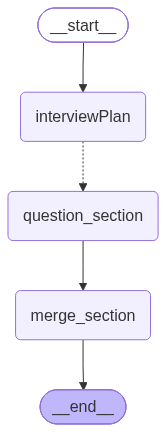

In [16]:
builder = StateGraph(InterviewState)

builder.add_node("interviewPlan", interviewPlan)
builder.add_node("question_section", question_section)
builder.add_node("merge_section", merge_section)

builder.add_edge(START, "interviewPlan")
builder.add_conditional_edges(
    "interviewPlan",
    question_workers,
    ["question_section"]
)
builder.add_edge("question_section", "merge_section")
builder.add_edge("merge_section", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
request = "나는 풀스택 개발자고 현재 ai에이전트 과정을 배우면서 langchain, langgraph에 대해서 배우고 있어, 파이썬과 자바를 언어로 써"

result = graph.invoke({'request' : request})
print(result['final_result'])

질문: LangChain과 LangGraph를 활용하여 복잡한 AI 에이전트 워크플로우를 설계할 때, 기존 LangChain의 AgentExecutor 대비 LangGraph가 갖는 주요 특징과 상태 관리(State Management) 구현 방식을 설명해주세요.
모범 답안: LangGraph는 순환(Cyclic) 그래프 구조를 지원하여 단순한 단방향 실행을 넘어 루프, 분기, 인간 개입(Human-in-the-loop)이 포함된 복잡한 에이전트 워크플로우를 구현할 수 있습니다. 기존 LangChain이 상태를 암묵적으로 전달했다면, LangGraph는 TypedDict 또는 Pydantic 기반의 명시적인 중앙 상태(State) 객체를 정의하고 각 노드(Node)가 상태를 업데이트하는 방식을 사용합니다. 또한 체크포인터(Checkpointer)를 통해 에이전트의 중간 상태를 내구성 있게 저장하고 재개할 수 있어 타임트래블 및 안정적인 multi-agent 제어가 가능합니다.

질문: Python 기반의 AI 서비스와 Java(Spring Boot) 백엔드 시스템을 연동할 때, 동기 및 비동기 통신 방식의 선택 기준과 효율적인 데이터 처리 및 통신 구조 설계 방안을 설명해주세요.
모범 답안: 실시간 응답이 필요하고 처리 시간이 짧은 요청은 REST API 또는 gRPC를 활용한 동기 통신으로 처리합니다. 특히 gRPC는 Protocol Buffers 기반의 바이너리 직렬화를 사용하여 데이터 크기를 경량화하고 직렬화 및 역직렬화 성능을 극대화할 수 있습니다. 반면, 대용량 데이터 처리나 시간이 오래 걸리는 AI 추론 작업은 Kafka나 RabbitMQ와 같은 메시지 브로커를 활용한 비동기 이벤트 기반 아키텍처로 설계합니다. Java 백엔드가 작업 요청 이벤트를 발행하면 Python AI 서비스가 이를 수신하여 비동기로 처리한 뒤 결과를 DB나 메시지 큐로 반환하며, 클라이언트에는 SSE 또는 WebSocket을 통해 응답을 전달하여 시스템 간 결합도를 낮추고 가

In [ ]:
# structed output
# class Interview_plan(basemodel):
#   section: list[Section] = Field(description="면접에 질문에 관한 분류, 평가할 내용을 담은 리스트 ")

# interviewState
#       request: str
#       section: list
#       result: Annotated[list, operator.add]
#       final_result: str

# - request로 받는다.(직무, 경력, 자격증)
# - request를 바탕으로 계획을 작성한다.
# -> 입력된 정보를 바탕으로 평가역량 판단 llm이 생성
# -> 기본 구조
#    ex) 분류 : {파이썬}
#    ex) 평가할내용 : {파이썬에 대한 이해도 평가}



#  structed output에 저런식으로 들어가면 된다. 
#  class Section(basemodel):
#       classification: str = Field(description="면접에 질문에 관한 분류")
#       questionDetail: str = Field(description="분류에 대한 평가할 내용")


# 이거는 SectionWorkerState 
#       request: str
#       classification: str
#       questionDetail: str
#       problem: str   -> 이거 제거
#       correct_answer: str     -> 이거 제거       

# - 각 worker에게 send로 분배한다.
# -> 구조
#    입력 정보(requset) :
#    분류 :
#    평가할 내용 :
#    문제 :  -> 이거 제거 
#    정답 :  -> 이거 제거 


# - 각 worker에 맞게 만들어 준다.
# -> 받은 구조로 문제를 만들고 리스트에 업데이트 한다.
# worker는 분류, 평가할 내용을 받아 문제, 정답을 만들어 업데이트한다.


# - 이후 하나의 면접 문제로 합친다. 
# -> 합친 후 면접 문제 리스트를 출력한다.

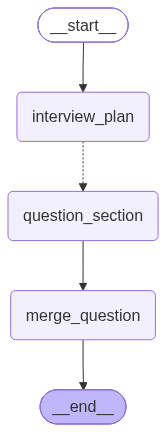

In [20]:
class Section(BaseModel):
    classification: str = Field(description="면접 질문에 관한 분류")
    question_detail: str = Field(description="분류에 대한 평가할 내용")


class InterviewPlan(BaseModel):
    sections: list[Section] = Field(description="면접에 질문에 관한 분류, 평가할 내용을 담은 리스트")

# Section 부분
class SectionWorkerState(TypedDict):
    request: str
    classification: str
    question_detail: str

# 전체
class InterviewState(TypedDict):
    request: str
    sections: list[Section]
    results: Annotated[list, operator.add]
    final_result: str    

llm_with_interviewplan_output = llm.with_structured_output(InterviewPlan)

# 면접자의 정보를 받고 리스트를 만든다
def interview_plan(state : InterviewState):
    request = state['request']

    response = llm_with_interviewplan_output.invoke(f"""
    지원자의 정보 {request}를 바탕으로 면접 질문에 관한 분류, 분류에 대한 평가할 내용을 한문장으로 정확히 5개 만들어줘.
    """)
    return {"sections" : response.sections}


# 리스트를 분배하는 역할
def assign_sections(state: InterviewState):
    return [
        Send (
            "question_section",
            {
                "request": state['request'],
                "classification": section.classification,
                "question_detail": section.question_detail
            }
        )
        for section in state["sections"]
    ]


# worker
def question_section(state: SectionWorkerState):
    request = state['request']
    classification = state['classification']
    question_detail = state['question_detail']

    response = llm.invoke(f"""
    지원자의 정보 {request}에 따른 {classification}와{question_detail}을 바탕으로 문제와 정답을 알려줘
    꼭 한문장으로 질문 1개와 모범답안 1개로 만들어줘
    마크다운 형식으로 깔끔하게 문제와 정답을 구성해서 알려줘,

    반드시 다음 형식으로 작성해줘.

    ### 질문
    질문 내용

    ### 모범 답안
    모범 답안 내용
    """)
    return {"results" : [{

        "classification": state['classification'],
        "question_detail": state['question_detail'],
        "content": response.text
    }]}

# worker 합치기
def merge_question(state: InterviewState):
    results = state['results']

    final_result = "\n\n".join([
        f"""
        classification : {result["classification"]} \n
        question_detail : {result["question_detail"]} \n
        content : {result["content"]} 
        """
        for result in results
    ])
    return {'final_result' : final_result}


builder = StateGraph(InterviewState)

builder.add_node('interview_plan', interview_plan)
builder.add_node('question_section', question_section)
builder.add_node('merge_question', merge_question)

builder.add_edge(START, 'interview_plan')
builder.add_conditional_edges(
    'interview_plan',
    assign_sections,
    ['question_section']
)

builder.add_edge("question_section", "merge_question")
builder.add_edge("merge_question", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
request = """
지원 직무: 신입 AI 백엔드 개발자
경력: 신입
프로젝트 경험: Python, FastAPI, LangGraph를 활용한 AI 서비스 개발
자격증: 정보처리산업기사
추가 : 개발을 배운지 8개월이며, 신입 기준에 맞게 내줘
"""
result = graph.invoke({'request' : request})

print(result['final_result'])


        classification : Python 및 FastAPI 기초역량 

        question_detail : Python의 기본 언어 특성과 FastAPI 프레임워크를 활용한 RESTful API 구현 능력을 평가합니다. 

        content : ### 질문
Python의 타입 힌팅(Type Hinting) 특성을 활용하여 FastAPI에서 요청 본문(Request Body) 데이터를 검증하고 RESTful API 엔드포인트를 구현하는 원리를 설명해 주세요.

### 모범 답안
FastAPI는 Python의 표준 타입 힌팅을 Pydantic 모델과 결합하여 클라이언트가 보낸 요청 데이터를 자동으로 검증 및 변환하고, 데이터 형식이 맞지 않을 경우 자동으로 422 에러 응답을 반환하여 안전한 RESTful API를 구현합니다. 
        


        classification : LangGraph 기반 AI 서비스 개발 능력 

        question_detail : LangGraph를 활용한 상태 기반 AI 워크플로우 설계 및 연동 과정에서의 이해도를 평가합니다. 

        content : ### 질문
LangGraph를 활용한 AI 워크플로우 개발 시, 노드 간 데이터 전달 및 흐름 제어를 위한 '상태(State)'의 역할과 이를 정의하여 활용하는 방식에 대해 설명해 주세요.

### 모범 답안
LangGraph의 상태(State)는 워크플로우 전체에서 공유되는 데이터 구조로, TypedDict 등을 활용해 필요한 데이터 스키마를 정의한 뒤 각 노드가 이 상태를 전달받아 데이터를 읽고 업데이트하며 에이전트의 실행 흐름을 제어하는 역할을 합니다. 
        


        classification : 백엔드 기초 및 데이터베이스 이해도 

        question_detail : 백엔드 개발에 필요한 비동기 처리 및 데이터베이스 연동 등 기본 동작 원리 이해도를 평가합니다. 

